In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# neighbor pairs

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep'
        ]

ref = 'bipolar'
xcorr_paths = []
for t in task:
    xcorr_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='xcorr',
            suffix='wave',
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
xcorrs = []
for path in tqdm(xcorr_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    xcorrs.append(df)

xcorrs = pd.concat(xcorrs)

# rename INS to 'Insula'
xcorrs.head()

100%|██████████| 129/129 [00:06<00:00, 20.44it/s]


,subject,task,phase,description,band,source,target,source_roi,source_label,source_hemi,...,source_z,target_roi,target_label,target_hemi,target_x,target_y,target_z,is_neighbor,lag,xcorr
0,D0023,PhonemeSequence,Response,Repeat,highgamma,D0023_R2IF1-2,D0023_R1MF11-12,INS,ctx_rh_S_circular_insula_sup,R,...,18.614382,IFGs,ctx_rh_S_front_inf,R,44.88676,2.823622,35.046768,False,-0.500000,0.020054
1,D0023,PhonemeSequence,Response,Repeat,highgamma,D0023_R2IF1-2,D0023_R1MF11-12,INS,ctx_rh_S_circular_insula_sup,R,...,18.614382,IFGs,ctx_rh_S_front_inf,R,44.88676,2.823622,35.046768,False,-0.492188,0.019704
2,D0023,PhonemeSequence,Response,Repeat,highgamma,D0023_R2IF1-2,D0023_R1MF11-12,INS,ctx_rh_S_circular_insula_sup,R,...,18.614382,IFGs,ctx_rh_S_front_inf,R,44.88676,2.823622,35.046768,False,-0.484375,0.019026
3,D0023,PhonemeSequence,Response,Repeat,highgamma,D0023_R2IF1-2,D0023_R1MF11-12,INS,ctx_rh_S_circular_insula_sup,R,...,18.614382,IFGs,ctx_rh_S_front_inf,R,44.88676,2.823622,35.046768,False,-0.476562,0.018222
4,D0023,PhonemeSequence,Response,Repeat,highgamma,D0023_R2IF1-2,D0023_R1MF11-12,INS,ctx_rh_S_circular_insula_sup,R,...,18.614382,IFGs,ctx_rh_S_front_inf,R,44.88676,2.823622,35.046768,False,-0.468750,0.017514


In [16]:
xcorrs[xcorrs.is_neighbor==True].source.unique()

array(['D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0032_LAI4-5',
       'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3',
       'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5',
       'D0125_LIA7-8'], dtype=object)

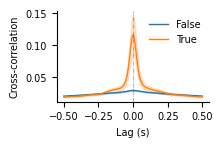

In [4]:
fig,ax = plt.subplots(figsize=(5*cm, 3*cm))

sns.lineplot(
    data = xcorrs,
    x='lag',
    hue='is_neighbor',
    y='xcorr',
    ax=ax,
    lw=1,
)

ax.set_xlabel('Lag (s)', fontsize=fontsize)
ax.set_ylabel('Cross-correlation', fontsize=fontsize)
sns.despine()

# rename legend and set title fontsize
ax.legend_.set_title('Is neighbor')
ax.legend_.get_title().set_fontsize(7)

for ax in fig.axes:
    ax.axvline(0, color='k', lw=0.5, alpha=0.4, ls='-.')
    ax.legend(fontsize=fontsize, frameon=False)
    ax.tick_params(labelsize=fontsize)
    
    
plt.savefig('../img/misc/neighbor_xcorr.svg', dpi=300, bbox_inches='tight')

# Ortho

In [5]:
# Ortho: load H5 (xarray) and concat across subjects
import xarray as xr

ref = 'bipolar'
ortho_paths = []
for t in task:
    ortho_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='xcorr',
            suffix='ortho',
            extension='.h5',
            check=False,
        ).match()
    )


def open_ortho(path):
    try:
        return xr.open_dataset(path, engine='h5netcdf')
    except Exception:
        return xr.open_dataset(path, engine='netcdf4')


def normalize_ds(ds):
    subject = ds.attrs.get('subject', 'unknown')
    task_name = ds.attrs.get('task', 'unknown')
    phase = ds.attrs.get('phase', 'unknown')
    desc = ds.attrs.get('description', 'unknown')
    band = ds.attrs.get('band', 'unknown')
    pair = ds['pair'].astype(str).values
    ds = ds.assign_coords(
        pair=[f"{subject}:{p}" for p in pair],
        subject=('pair', np.repeat(subject, len(pair))),
        task=('pair', np.repeat(task_name, len(pair))),
        phase=('pair', np.repeat(phase, len(pair))),
        description=('pair', np.repeat(desc, len(pair))),
        band=('pair', np.repeat(band, len(pair))),
    )
    return ds


datasets = [normalize_ds(open_ortho(p).load()) for p in tqdm(ortho_paths)]

# concat along pair (pair names are prefixed with subject for uniqueness)
ds_all = xr.concat(datasets, dim='pair')

ds_all

100%|██████████| 27/27 [00:03<00:00,  7.61it/s]


<xarray.Dataset> Size: 50MB
Dimensions:       (pair: 32, trial: 203, time: 320, variant: 2, lag: 129)
Coordinates: (12/13)
  * trial         (trial) int64 2kB 0 1 2 3 4 5 6 ... 197 198 199 200 201 202
  * time          (time) float64 3kB -1.0 -0.9922 -0.9844 ... 1.477 1.484 1.492
  * lag           (lag) float64 1kB -0.5 -0.4922 -0.4844 ... 0.4844 0.4922 0.5
  * variant       (variant) <U6 48B 'before' 'after'
  * pair          (pair) <U34 4kB 'D0040:D0040_L1IF3-4__D0040_L1IF4-5' ... 'D...
    source        (pair) <U13 2kB 'D0040_L1IF3-4' ... 'D0125_LIA7-8'
    ...            ...
    is_neighbor   (pair) bool 32B True True True True ... True True True True
    subject       (pair) <U5 640B 'D0040' 'D0084' 'D0086' ... 'D0125' 'D0125'
    task          (pair) <U15 2kB 'PhonemeSequence' ... 'PictureNaming'
    phase         (pair) <U8 1kB 'Response' 'Response' ... 'Response' 'Response'
    description   (pair) <U8 1kB 'Repeat' 'Repeat' ... 'Repeat' 'Repeat'
    band          (pair) <U9 1kB 'highgamma' 'highgamma' ... 'highgamma'
Data variables:
    insula        (pair, trial, time) float64 17MB -1.108 -1.147 ... nan nan
    ifg           (pair, trial, time) float64 17MB -0.6105 -0.7528 ... nan nan
    insula_ortho  (pair, trial, time) float64 17MB -0.7685 -0.7284 ... nan nan
    xcorr         (pair, variant, lag) float32 33kB nan nan nan ... 0.0211 0.022
Attributes:
    subject:      D0040
    task:         PhonemeSequence
    phase:        Response
    description:  Repeat
    band:         highgamma

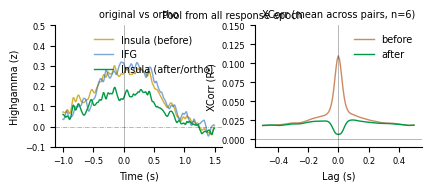

In [6]:
# Before/after: highgamma traces (mean across pair+trial)
trace_dims = ('pair', 'trial')
mean_insula = ds_all['insula'].mean(dim=trace_dims, skipna=True)
mean_ifg = ds_all['ifg'].mean(dim=trace_dims, skipna=True)
mean_ortho = ds_all['insula_ortho'].mean(dim=trace_dims, skipna=True)

# Before/after: xcorr curves (mean across pairs)
xcorr_mean = ds_all['xcorr'].mean(dim='pair', skipna=True)

time = ds_all['time'].values

fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 4 * cm), sharey=False)

axes[0].plot(time, mean_insula, color=insula_color, lw=1, label='Insula (before)')
axes[0].plot(time, mean_ifg, color=blue, alpha=0.6, lw=1, label='IFG')
axes[0].plot(time, mean_ortho, color=green, lw=1, label='Insula (after/ortho)')

axes[0].set_title('original vs ortho', fontsize=fontsize)
axes[0].set_xlabel('Time (s)', fontsize=fontsize)
axes[0].set_ylabel('Highgamma (z)', fontsize=fontsize)

for variant, color in zip(['before', 'after'], [orange, green]):
    axes[1].plot(ds_all['lag'], xcorr_mean.sel(variant=variant), color=color, label=variant, lw=1)

axes[1].axhline(0, color='k', lw=0.5, alpha=0.4)
axes[1].set_title('XCorr (mean across pairs, n=6)', fontsize=fontsize)
axes[1].set_xlabel('Lag (s)', fontsize=fontsize)
axes[1].set_ylabel('XCorr (R²)', fontsize=fontsize)

for ax in axes:
    ax.axvline(0, color='k', lw=0.5, alpha=0.4)
    ax.legend(fontsize=fontsize, frameon=False)
    ax.tick_params(labelsize=fontsize - 1)

axes[0].axhline(0, color='k', lw=0.5, alpha=0.4, ls='-.')
axes[1].set_ylim(-0.01, 0.15)
axes[0].set_ylim(-0.1, 0.5)

plt.suptitle('Pool from all response epoch', fontsize=fontsize)
sns.despine()

plt.savefig('../img/misc/insula_ortho.svg', dpi=300, bbox_inches='tight')

In [12]:
np.unique(ds_all.pair)

array(['D0032:D0032_LAI4-5__D0032_LAI5-6',
       'D0040:D0040_L1IF3-4__D0040_L1IF4-5',
       'D0084:D0084_RFAI1-2__D0084_RFAI2-3',
       'D0086:D0086_LTPI2-3__D0086_LTPI3-4',
       'D0090:D0090_RIA4-5__D0090_RIA5-6',
       'D0096:D0096_LFAI2-3__D0096_LFAI3-4',
       'D0096:D0096_LFAI4-5__D0096_LFAI3-4',
       'D0102:D0102_RFAI2-3__D0102_RFAI3-4',
       'D0106:D0106_LTAS2-3__D0106_LTAS3-4',
       'D0121:D0121_LFMI3-4__D0121_LFMI4-5',
       'D0122:D0122_LFAI3-4__D0122_LFAI4-5',
       'D0125:D0125_LIA4-5__D0125_LIA5-6',
       'D0125:D0125_LIA7-8__D0125_LIA6-7'], dtype='<U34')